In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P1 - Peeking / optional stopping

## 1. What goes wrong
You check the p-value every day and stop as soon as it dips below 0.05. Each look is another chance for noise to cross the line.

## 2. Simulate

In [2]:
from abtest.pitfalls import peeking
from abtest.analyze.sequential import calibrate_obf
looks = peeking.fpr_by_looks(n_sims=5_000)
looks

,looks,fpr
0,1,0.0476
1,2,0.0818
2,3,0.1104
3,5,0.1448
4,7,0.1660
5,14,0.2218
6,28,0.2836
7,56,0.3104


## 3. Quantify the damage

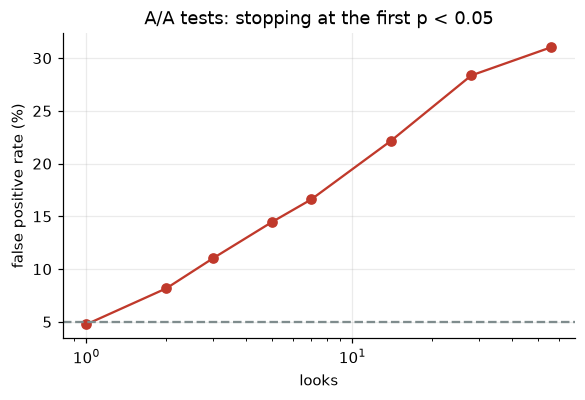

1 look: 4.8%   14 looks: 22.2%


In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(looks.looks, looks.fpr * 100, 'o-', color=BAD); ax.axhline(5, color=NEUTRAL, ls='--')
ax.set(xscale='log', xlabel='looks', ylabel='false positive rate (%)', title='A/A tests: stopping at the first p < 0.05'); plt.show()
print(f"1 look: {looks.fpr.iloc[0]:.1%}   14 looks: {looks[looks.looks == 14].fpr.iloc[0]:.1%}")

## 4. Detect

Count how many times the analysis was looked at and whether it was stopped on a fixed-horizon p-value. In the health checker this is the **Peeking** check (red if stopped early without a sequential method).

## 5. Fix

Two fixes. **O'Brien-Fleming** boundaries need the looks planned in advance (strict early, about 1.96 at the end). **mSPRT** gives always-valid p-values for any number of looks. The O'Brien-Fleming constant is calibrated by simulation and sanity-checked against the published value (about 2.04 for 5 looks).

In [4]:
print('K=5 constant:', round(calibrate_obf(5, n_sims=100_000), 3), '(published ~2.04)')

K=5 constant: 2.044 (published ~2.04)


## 6. Verify the fix

In [5]:
null = peeking.compare_methods(rel_lift=0.0, n_sims=5_000); alt = peeking.compare_methods(rel_lift=0.10, n_sims=5_000)
rows = [{'method': m, 'false positive rate': null[m]['reject_rate'], 'power at +10% lift': alt[m]['reject_rate'], 'avg looks used (real effect)': alt[m]['avg_looks_used']} for m in ['fixed_horizon','naive_peeking','obrien_fleming','msprt']]
print(pd.DataFrame(rows).round(3).to_string(index=False))
print()
print(peeking.msprt_sample_cost(n_sims=3_000).round(3).to_string(index=False))

        method  false positive rate  power at +10% lift  avg looks used (real effect)
 fixed_horizon                0.048               0.751                        14.000
 naive_peeking                0.216               0.841                         7.060
obrien_fleming                0.049               0.730                        11.059
         msprt                0.002               0.286                        13.087



 sample_multiplier  msprt_power
              1.00        0.419
              1.25        0.540
              1.50        0.664
              2.00        0.813
              2.50        0.901
              3.00        0.953


## So what
Daily peeking inflates false positives several-fold. O'Brien-Fleming fixes it at almost no cost in power. mSPRT also fixes it, but it is conservative at a fixed horizon: it needs about twice the sample for the same power. That is the price of being allowed to look at any time.